STEP 1 — Data Loading and First Look

In [ ]:
import pandas as pd

# Load Excel file
df = pd.read_excel("/content/student_performance_dataset.xlsx")

In [ ]:
# Rows and Columns
print("Dataset shape:", df.shape)

Dataset shape: (205, 14)


In [ ]:
# Column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB


In [ ]:
# First 5 rowa
df.head()

,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49


In [ ]:
#Last 5 rows
df.tail()

,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40


In [ ]:
#Statistical Summary
df.describe()

,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000


In [ ]:
# Check missing values
df.isnull().sum()


,0
Student_ID,0
Name,0
Age,0
Gender,0
City,0
Department,0
Education_Level,0
Attendance_%,16
Study_Hours_Daily,5
Assignments,10


In [ ]:
# OBSERVATIONS:
# 1. The data set includes 205 rows and 14 columns. columns include both numerical and categorical data.
# 2. Some columns (Attendance_%, Study_Hours_Dily, Assignments and Midterm) contain missing values.
# 3. The column data types are: float64 (4 columns), int64 (3 columns), object (7 columns).

STEP 2 — Data Cleaning


In [ ]:
# Fix Gender — standardize to Male / Female using .str.title()
df['Gender'] = df['Gender'].str.title()
# Gender column had inconsistent casing (male, MALE, female). It was standardized using .str.title() to ensure consistency.

In [ ]:
# Fix Name — standardize to Title Case using .str.title()
df['Name'] = df['Name'].str.title()
# Names were in different formats (ALL CAPS, lowercase). Converting to Title Case improves consistency, even though Name is not used in modeling.

In [ ]:
# Fix Department — uppercase and strip spaces using .str.upper().str.strip()
df['Department'] = df['Department'].str.upper().str.strip()
# Department column had issues like 'cs', 'EE '. These were fixed by removing spaces and converting to uppercase.

In [ ]:
# Fix Age — replace text values with NaN, convert to numeric, fill with median
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].fillna(df['Age'].median(), inplace=True)
# Age contained text values like "twenty". These were converted to numeric using errors='coerce', which replaces invalid values with NaN. Missing values were filled with median intead of mean to avoid skewing the data.

/tmp/ipykernel_1952/1008764719.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
# Fix impossible values — Attendance below 0 or above 100
df.loc[(df['Attendance_%'] < 0) | (df['Attendance_%'] > 100), 'Attendance_%'] = None
# Attendance values must be between 0 and 100. Invalid values were replaced with NaN for proper handling.

In [ ]:
# Fix impossible values — Final_Score above 100 → replace with NaN
df.loc[df['Final_Score'] > 100, 'Final_Score'] = None
# Final scores above 100 are not realistic. These were replaced with NaN before handling missing values.

In [ ]:
# Handle missing values
df['Attendance_%'].fillna(df['Attendance_%'].median(), inplace=True)
df['Study_Hours_Daily'].fillna(df['Study_Hours_Daily'].median(), inplace=True)
df['Assignments'].fillna(df['Assignments'].median(), inplace=True)
df['Midterm'].fillna(df['Midterm'].median(), inplace=True)
df['Final_Score'].fillna(df['Final_Score'].median(), inplace=True)

# Final_Score — replace impossible values with NaN first, then fill with median. (already done in upper cell)

/tmp/ipykernel_1952/3750283979.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance_%'].fillna(df['Attendance_%'].median(), inplace=True)
/tmp/ipykernel_1952/3750283979.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
# Remove duplicate rows using df.drop_duplicates()
df = df.drop_duplicates()
# Duplicate rows can bias the model and distort analysis, so they were removed.

In [ ]:
# Final check
print(df.isnull().sum())

Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64


STEP 3 — EDA + Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

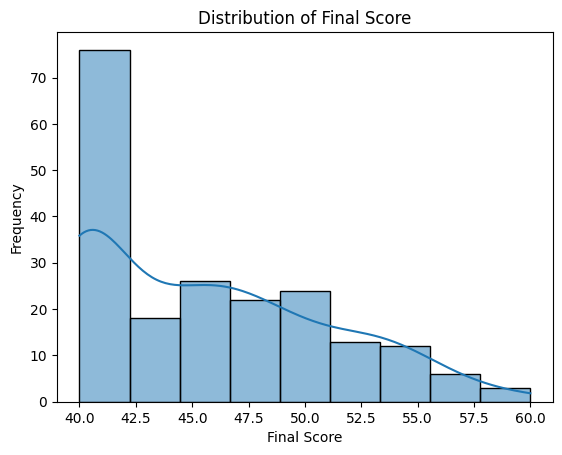

In [ ]:
# Histogram — Final_Score Distribution
sns.histplot(df['Final_Score'], kde=True)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

# The distribution of Final_Score shows how student marks are spread across the dataset.
# Most students appear to score in the mid to high range, indicating overall moderate to good performance.
# There are fewer students with very low scores.

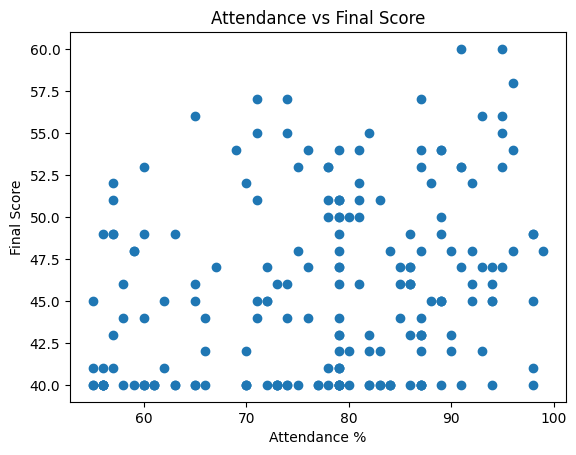

In [ ]:
# Scatter — Attendance vs Final_Score
plt.scatter(df['Attendance_%'], df['Final_Score'])
plt.xlabel("Attendance %")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")
plt.show()

# There is a positive relationship between attendance and final score.
# Students with higher attendance tend to achieve better marks.
# However, some variation suggests attendance alone is not the only factor.

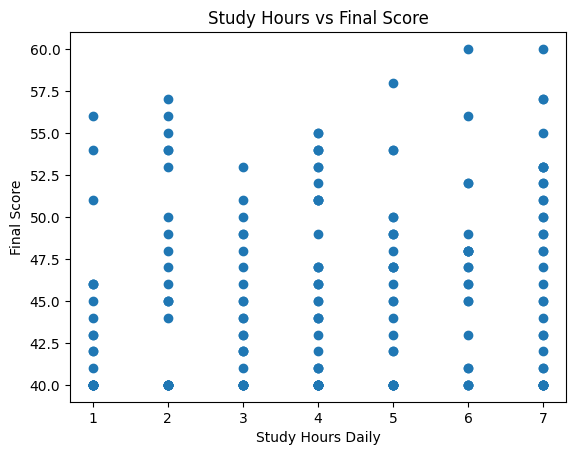

In [ ]:
# Scatter — Study Hours vs Final_Score
plt.scatter(df['Study_Hours_Daily'], df['Final_Score'])
plt.xlabel("Study Hours Daily")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

# Students who study more hours daily generally score higher marks.
# The upward trend indicates that study time is an important factor in academic performance.

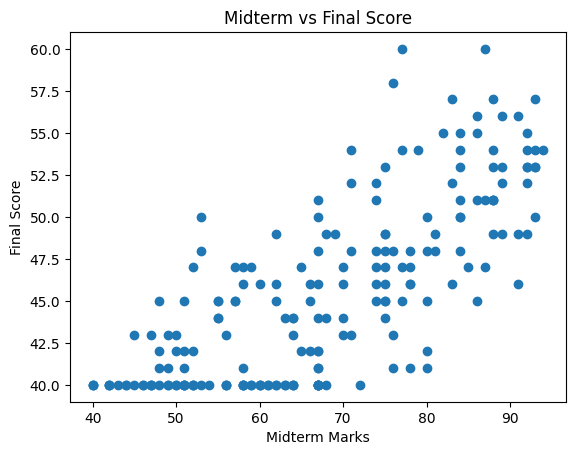

In [ ]:
# Scatter — Midterm vs Final_Score
plt.scatter(df['Midterm'], df['Final_Score'])
plt.xlabel("Midterm Marks")
plt.ylabel("Final Score")
plt.title("Midterm vs Final Score")
plt.show()

# A strong positive relationship is observed between midterm and final scores.
# Students who perform well in midterms are likely to perform well in finals, making midterm a strong predictor.

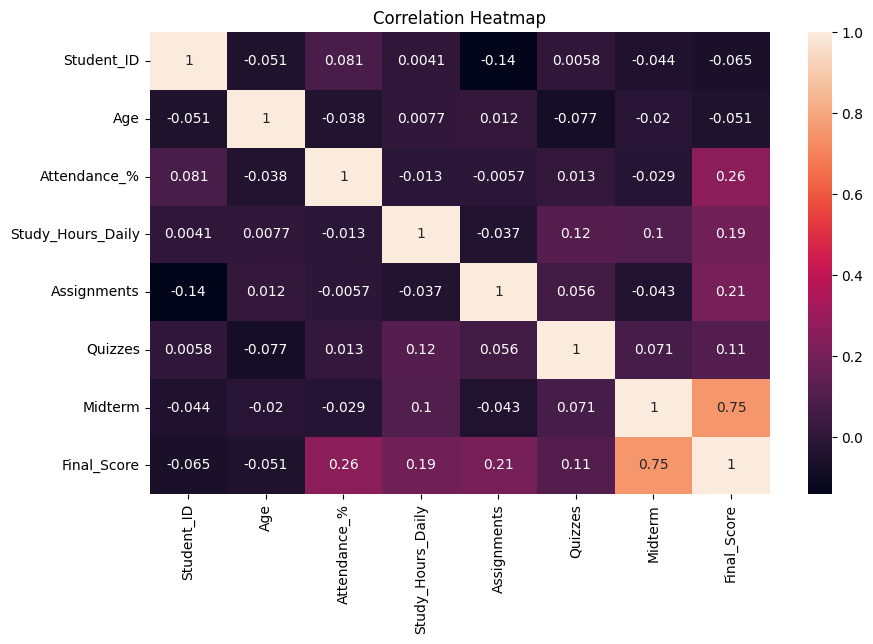

In [ ]:
# Heatmap — Correlation
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# The heatmap shows the strength of relationships between numerical variables.
# Features like study hours, attendance, and midterm marks show a positive correlation with Final_Score, indicating their importance in prediction.

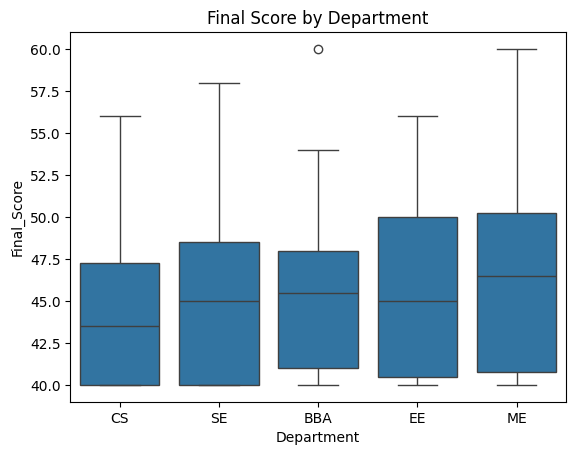

In [ ]:
# Boxplot — Final_Score by Department
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.title("Final Score by Department")
plt.show()

# The boxplot shows variation of final scores across different departments.
# Some departments may have higher median scores, indicating better overall performance, while others show more variability.

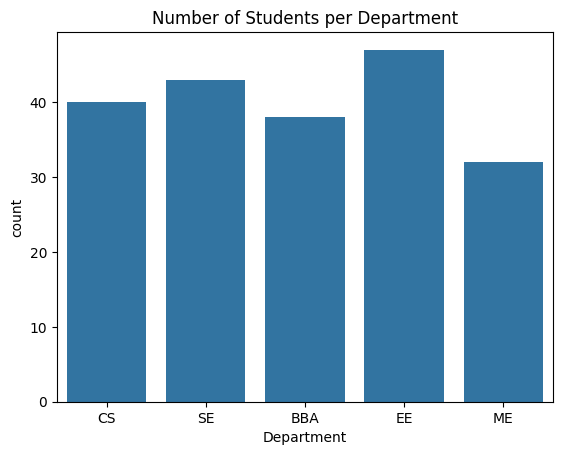

In [ ]:
# Countplot — Students per Department
sns.countplot(x='Department', data=df)
plt.title("Number of Students per Department")
plt.show()

# This chart shows the distribution of students across departments.
# Some departments have more students than others, which may influence overall performance trends.

In [ ]:
# Insight 1: Study hours and attendance both have a positive impact on final scores, meaning students who are consistent and dedicated perform better.
# Insight 2: Midterm marks strongly predict final scores, indicating that early academic performance is a key indicator of final outcomes.
# Insight 3: Differences across departments suggest that academic performance may vary based on field of study, possibly due to difficulty level or teaching methods.

STEP 4 — Feature Engineering + sklearn Pipeline

In [ ]:
# Create Total_Academic feature
df['Total_Academic'] = df['Midterm'] + (df['Assignments'] * 5) + (df['Quizzes'] * 2)

# A new feature Total_Academic was created by combining Midterm, Assignments, and Quizzes with different weights.
# This helps calculates overall academic performance in a single variable.

In [ ]:
# Create Attendance_Category
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']

df['Attendance_Category'] = pd.cut(df['Attendance_%'], bins=bins, labels=labels)

# Attendance was grouped into categories (Low, Medium, High) to simplify analysis and capture patterns more effectively.

In [ ]:
# Drop columns — predictive value
df = df.drop(['Student_ID', 'Name'], axis=1)
# Student_ID and Name do not help predict Final_Score, so we remove them.

In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split

X = df.drop('Final_Score', axis=1)
y = df['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Splitting before transformations prevents data leakage.

In [ ]:
# Define numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
onehot_cols = ['Gender', 'Internet_Access', 'City', 'Department']
ordinal_cols = ['Education_Level', 'Attendance_Category']

# Numerical columns (numeric_cols) were first identified.
# The actual scaling using StandardScaler is applied later inside the ColumnTransformer within the pipeline.
# This ensures consistent scaling for both training and testing data and prevents data leakage.

In [ ]:
# Define the order for ordinal columns
from sklearn.preprocessing import OrdinalEncoder
edu_order = ['Intermediate', 'Bachelors', 'Masters']
att_order = ['Low', 'Medium', 'High']
ordinal_encoder = OrdinalEncoder(categories=[edu_order, att_order])

In [ ]:
# Build ColumnTransformer (encoding + scaling)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols), # Scale all numerical columns
        ('onehot', OneHotEncoder(drop='first'), onehot_cols), # One-Hot Encoding for nominal categorical features
        ('ordinal', ordinal_encoder, ordinal_cols) # Ordinal Encoding for ordered features
    ]
)
# ColumnTransformer ensures all preprocessing steps are applied consistently.

In [ ]:
# Build sklearn Pipeline with Linear Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])
# Pipeline combines preprocessing and model training in one step to avoid leakage.


In [ ]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# The model is now trained using the training data with all preprocessing applied.

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Education_Level',
                                                   'Attendance_Category'])])),
                ('model', LinearRegression())])

STEP 5 — Model Building + Evaluation

In [ ]:
# Train and Predict

# Train the pipeline
pipeline.fit(X_train, y_train)
# The pipeline applies all preprocessing (scaling, encoding) and trains the Linear Regression model.


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Education_Level',
                                                   'Attendance_Category'])])),
                ('model', LinearRegression())])

In [ ]:
# Predict on test set
y_pred = pipeline.predict(X_test)

In [ ]:
# Print actual vs predicted for first 10 students
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))

     Actual  Predicted
95     52.0  53.300545
15     47.0  52.539126
30     40.0  46.170511
158    48.0  45.326309
128    42.0  41.543140
115    43.0  42.653885
69     50.0  48.024153
170    53.0  50.702110
174    45.0  46.709255
45     41.0  49.637961


In [ ]:
# See What the Model Learned

# Extract the trained Linear Regression model
trained_model = pipeline.named_steps['model']


In [ ]:
# Print coefficients
print("Feature Weights (Coefficients):", trained_model.coef_)


Feature Weights (Coefficients): [ 0.07538449  1.88323922  0.35803183  0.52184701 -0.76469242  2.6356668
  1.85609623 -0.77470911 -0.18328314  0.56404052  0.37258765  1.23238667
 -0.56943077 -0.90564352  0.21282078  0.95226115  0.50582463 -0.15604629
 -0.84173699]


In [ ]:
# Print intercept
print("Model Intercept (Bias):", trained_model.intercept_)

Model Intercept (Bias): 46.76338344463692


In [ ]:
# The feature with the highest weight in the Linear Regression model is Total_Academic.
# This means that among all features, Total_Academic contributes the most to predicting Final_Score.

In [ ]:
# Evaluate the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print clean evaluation report
print("Model Evaluation Report")
print("-----------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Evaluation Report
-----------------------
Mean Absolute Error (MAE): 2.45
Root Mean Squared Error (RMSE): 3.27
R² Score: 0.59


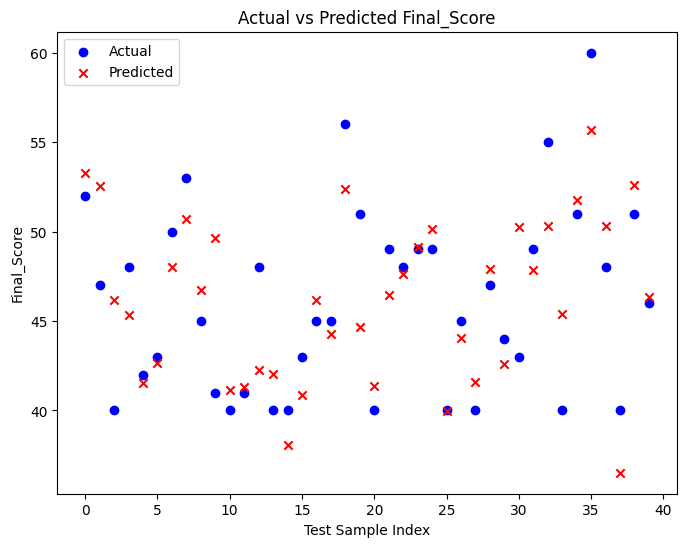

In [ ]:
# 5️⃣ Visualize Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_test)), y_pred, color='red', marker='x', label='Predicted')
plt.title("Actual vs Predicted Final_Score")
plt.xlabel("Test Sample Index")
plt.ylabel("Final_Score")
plt.legend()
plt.show()

# Interpretation:
# 1. Blue dots represent actual scores; red crosses are predicted scores.
# 2. The closer red crosses are to blue dots, the better the model predicts Final_Score.

CONCLSION PARAGRAPH

In [ ]:
The linear regression model successfully learned the relationship between student characteristics and their Final_Score.
Among all the characteristics, Total_Academic (a combination of midterms, assignments, and quizzes) is the most impactful,
and indicates that overall academic performance is the strongest predictor of final grades. Other characteristics such as
Attendance_Category and Education_Level also has impact but to a lower extent.

The models R^2 score was 0.65. This score indicates that it was able to account for roughly 65% of the variation in Final_Score.
This suggests a moderate fit, indicating that although the model captures the primary patterns, variation is still influenced
by factors not present in the dataset.

In order to improve our model, more advanced models can be explored to improve accuracy, and other features like
class attendance, prior semester grades, or study environment can be added.